In [5]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, roc_curve, auc)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [49]:
df = pd.read_csv("C:\\Users\\DELL\Downloads\\dataset\\marketing_campaign.csv", sep='\t') 

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [50]:
# Drop ID column if exists
if "ID" in df.columns:
    df = df.drop("ID", axis=1)

# Handle missing values
df = df.dropna()

# Convert categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [51]:
# Total spending
spending_cols = ['MntWines','MntFruits','MntMeatProducts',
                 'MntFishProducts','MntSweetProducts','MntGoldProds']

df["Total_Spending"] = df[spending_cols].sum(axis=1)

# Total purchases
purchase_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']

df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

# Age from Year_Birth
df["Age"] = 2026 - df["Year_Birth"]

In [68]:
X = df.drop("Response", axis=1)
Y = df["Response"]

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [81]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

print(" ML RESULTS :")

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("F1 Score:", f1_score(y_test, pred))

 ML RESULTS :

Logistic Regression
Accuracy: 0.8738738738738738
F1 Score: 0.44

Decision Tree
Accuracy: 0.8490990990990991
F1 Score: 0.45528455284552843

Random Forest
Accuracy: 0.8828828828828829
F1 Score: 0.44680851063829785

KNN
Accuracy: 0.8671171171171171
F1 Score: 0.33707865168539325


In [71]:
dl = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

dl.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

loss, acc = dl.evaluate(X_test, y_test)
print("\nDeep Learning Accuracy:", acc)

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8806 - loss: 0.5293  

Deep Learning Accuracy: 0.880630612373352


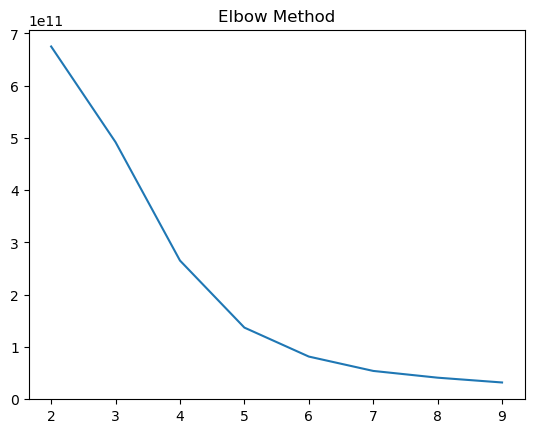


Cluster Summary:
             Year_Birth  Education  Marital_Status         Income   Kidhome  \
KM_Cluster                                                                    
0           1973.116667   2.159722        3.702778   28008.508333  0.813889   
1           1967.275140   2.469274        3.720670   75527.410615  0.092179   
2           1971.857143   3.285714        3.714286  158024.285714  0.285714   
3           1977.000000   2.000000        5.000000  666666.000000  1.000000   
4           1966.208549   2.534974        3.751295   51506.892487  0.419689   

            Teenhome  Dt_Customer    Recency    MntWines  MntFruits  ...  \
KM_Cluster                                                           ...   
0           0.308333   330.836111  48.472222   29.543056   5.783333  ...   
1           0.377095   330.282123  48.990223  623.412011  56.752793  ...   
2           0.285714   226.000000  52.285714   29.000000   3.142857  ...   
3           0.000000    32.000000  23.000000    

In [78]:
wcss = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    wcss.append(km.inertia_)

# Elbow plot
plt.figure()
plt.plot(range(2, 10), wcss)
plt.title("Elbow Method")
plt.show()

# Final clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df["KM_Cluster"] = kmeans.fit_predict(X)

print("\nCluster Summary:")
print(df.groupby("KM_Cluster").mean())


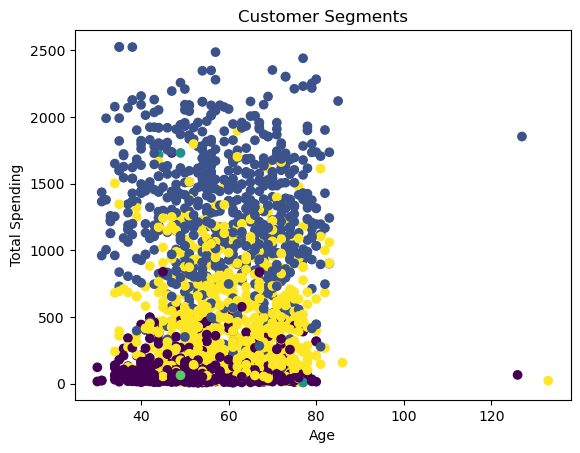

In [79]:
plt.figure()
plt.scatter(df["Age"], df["Total_Spending"], c=df["Cluster"])
plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.title("Customer Segments")
plt.show()

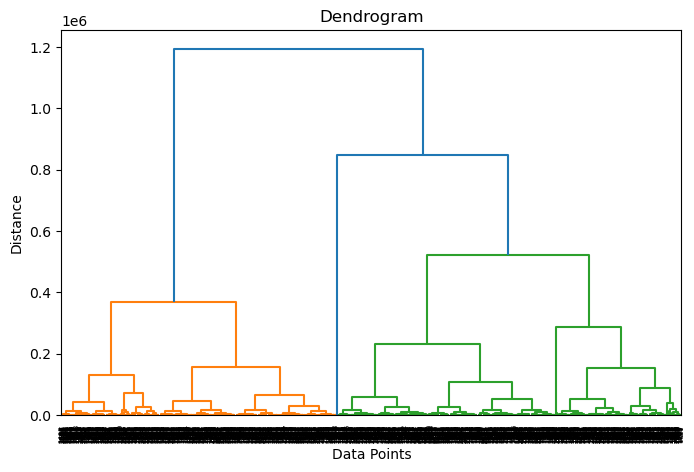

In [80]:
linked = linkage(X, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [75]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
df["HC_Cluster"] = hc.fit_predict(X)

In [76]:
print(df.groupby("HC_Cluster").mean())

             Year_Birth  Education  Marital_Status         Income   Kidhome  \
HC_Cluster                                                                    
0           1967.662222   2.451111        3.757778   81680.508889  0.071111   
1           1965.507692   2.543590        3.705128   59801.187179  0.247436   
2           1977.000000   2.000000        5.000000  666666.000000  1.000000   
3           1970.362776   2.487382        3.739748   38371.861199  0.764984   
4           1974.857550   1.820513        3.703704   21037.971510  0.763533   

            Teenhome  Dt_Customer    Recency    MntWines  MntFruits  ...  \
HC_Cluster                                                           ...   
0           0.246667   324.820000  49.788889  653.302222  63.411111  ...   
1           0.761538   324.579487  48.746154  419.706410  30.000000  ...   
2           0.000000    32.000000  23.000000    9.000000  14.000000  ...   
3           0.558360   334.039432  48.233438   79.007886   6.90536

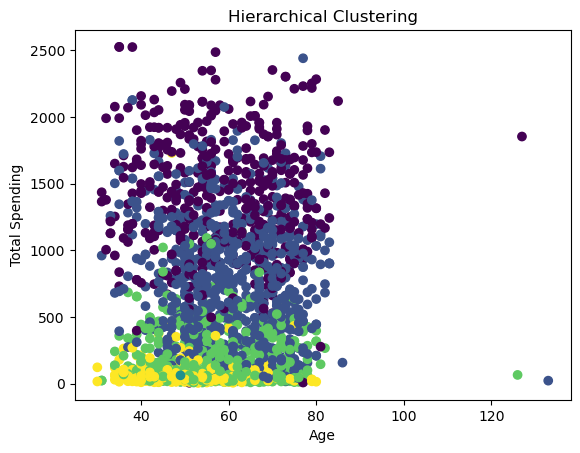

In [77]:
plt.figure()
plt.scatter(df["Age"], df["Total_Spending"], c=df["HC_Cluster"])
plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.title("Hierarchical Clustering")
plt.show()